In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
t_assoc = np.linspace(0, 180, 100)
t_dissoc = np.linspace(180, 360, 100)


k_on_rssb = 1e5
k_off_rssb = 1e-3
R_max_rssb = 100

k_on_swap = 1e5
k_off_swap = 1e-2
R_max_swap = 90

In [5]:
def calc_response(t_a, t_d, kon, koff, rmax, conc=1e-5):
    ka = kon * conc + koff
    req = (kon * conc * rmax) / ka
    resp_a = req * (1 - np.exp(-ka * t_a))

    r0 = resp_a[-1]
    resp_d = r0 * np.exp(-koff * (t_d - t_d[0]))
    return np.concatenate([resp_a, resp_d])

In [6]:
time = np.concatenate([t_assoc, t_dissoc])
curve_rssb = calc_response(t_assoc, t_dissoc, k_on_rssb, k_off_rssb, R_max_rssb)
curve_swap = calc_response(t_assoc, t_dissoc, k_on_swap, k_off_swap, R_max_swap)

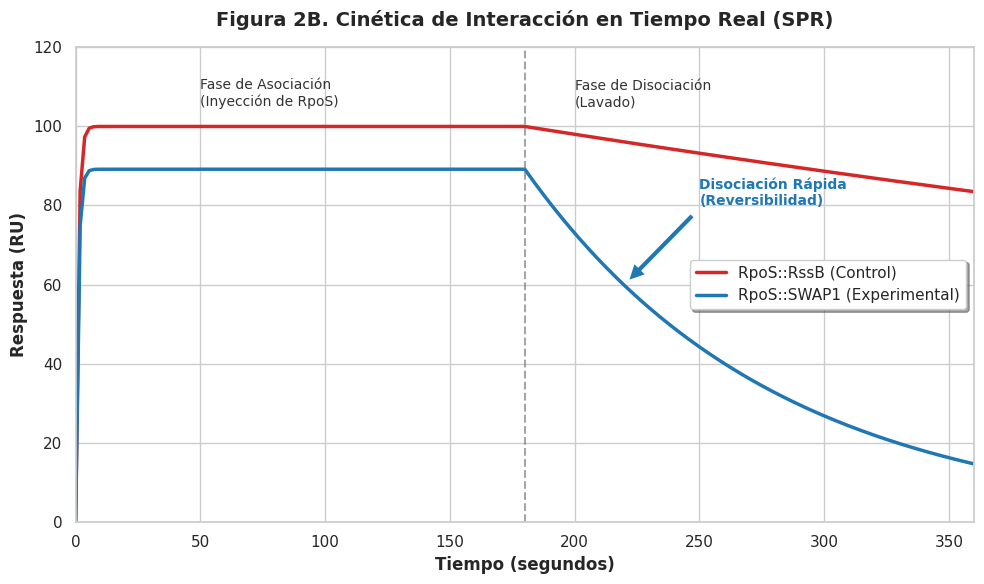

In [7]:
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

plt.plot(time, curve_rssb, color='#d62728', linewidth=2.5, label='RpoS::RssB (Control)')
plt.plot(time, curve_swap, color='#1f77b4', linewidth=2.5, label='RpoS::SWAP1 (Experimental)')

plt.title('Figura 2B. Cinética de Interacción en Tiempo Real (SPR)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tiempo (segundos)', fontsize=12, fontweight='bold')
plt.ylabel('Respuesta (RU)', fontsize=12, fontweight='bold')

plt.axvline(x=180, color='gray', linestyle='--', alpha=0.7)
plt.text(50, 105, 'Fase de Asociación\n(Inyección de RpoS)', fontsize=10, color='#333')
plt.text(200, 105, 'Fase de Disociación\n(Lavado)', fontsize=10, color='#333')


plt.annotate('Disociación Rápida\n(Reversibilidad)', xy=(220, 60), xytext=(250, 80),
             arrowprops=dict(facecolor='#1f77b4', shrink=0.05), fontsize=10, color='#1f77b4', fontweight='bold')

plt.legend(fontsize=11, loc='center right', frameon=True, shadow=True)
plt.ylim(0, 120)
plt.xlim(0, 360)

plt.tight_layout()
plt.savefig('Figura2B_SPR.png', dpi=300)
plt.show()